In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:/Users/viswa/OneDrive/Desktop/Sales Forecasting Dashboard/data/Sample - Superstore.csv")
df.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 2944: invalid start byte

In [2]:
import pandas as pd
df = pd.read_csv("C:/Users/viswa/OneDrive/Desktop/Sales Forecasting Dashboard/data/Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [7]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [8]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009


In [9]:
monthly_sales = (df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum())

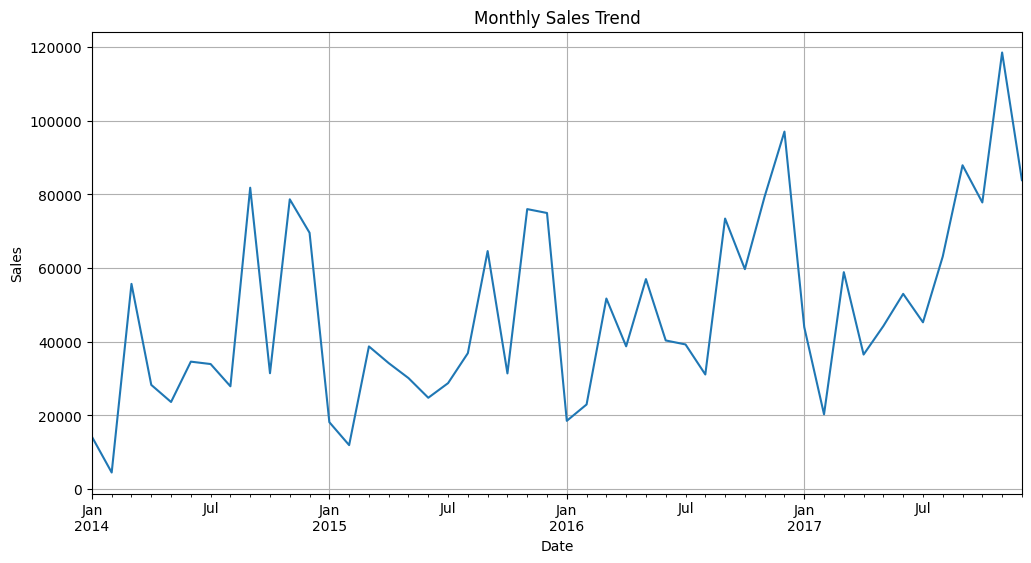

In [10]:
plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

From the Analysis of Monthly Sales Trend -> we can notice that there is a trend where sales in 2017 are noticeably higher than sales in 2014 
-> Strong Seasonality notice the repeated spikes near the year ends(holidays or year end sales surges) -> Forecasting is feasible

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


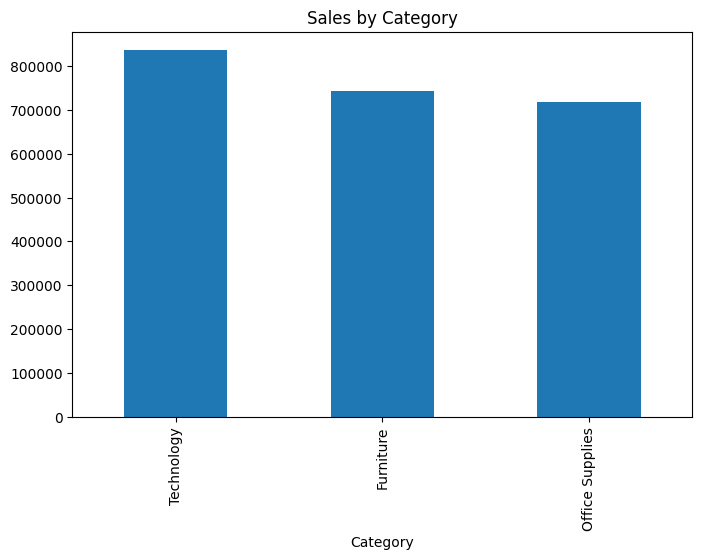

In [11]:
category_sales = (df.groupby('Category')['Sales'].sum().sort_values(ascending=False))
print(category_sales)
category_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Category")
plt.show()

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


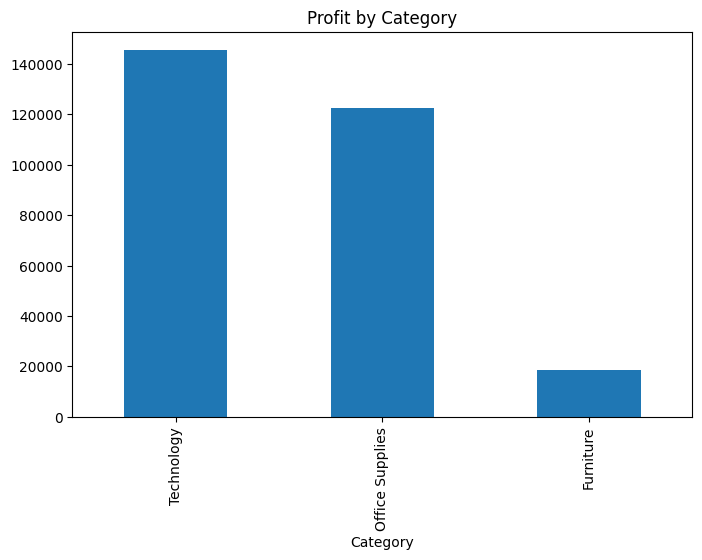

In [12]:
category_profit = (df.groupby('Category')['Profit'].sum().sort_values(ascending=False))
print(category_profit)
category_profit.plot(kind='bar', figsize=(8,5))
plt.title("Profit by Category")
plt.show()

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


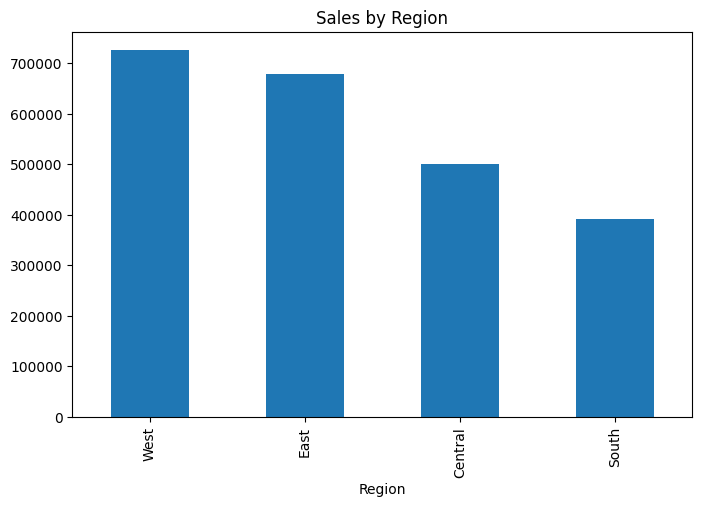

In [13]:
region_sales = (df.groupby('Region')['Sales'].sum().sort_values(ascending=False))
print(region_sales)
region_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Region")
plt.show()

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


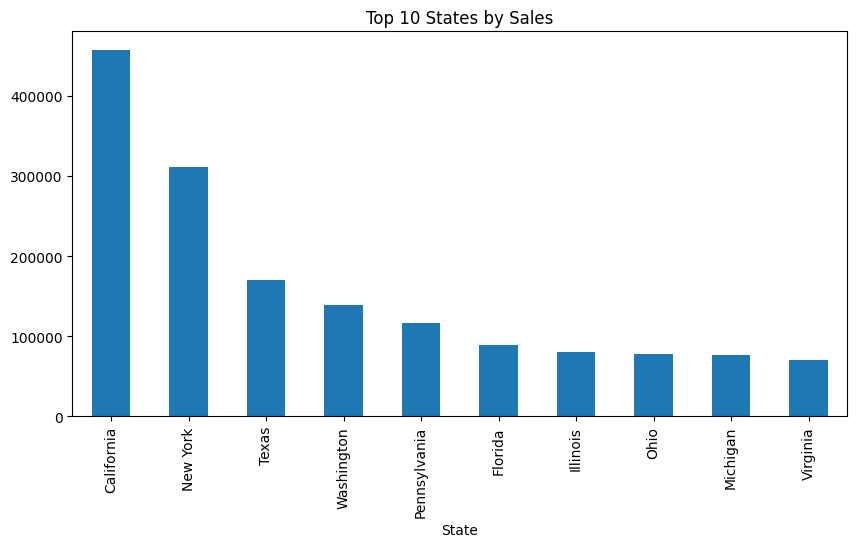

In [14]:
top_states = (df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10))
print(top_states)
top_states.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 States by Sales")
plt.show()

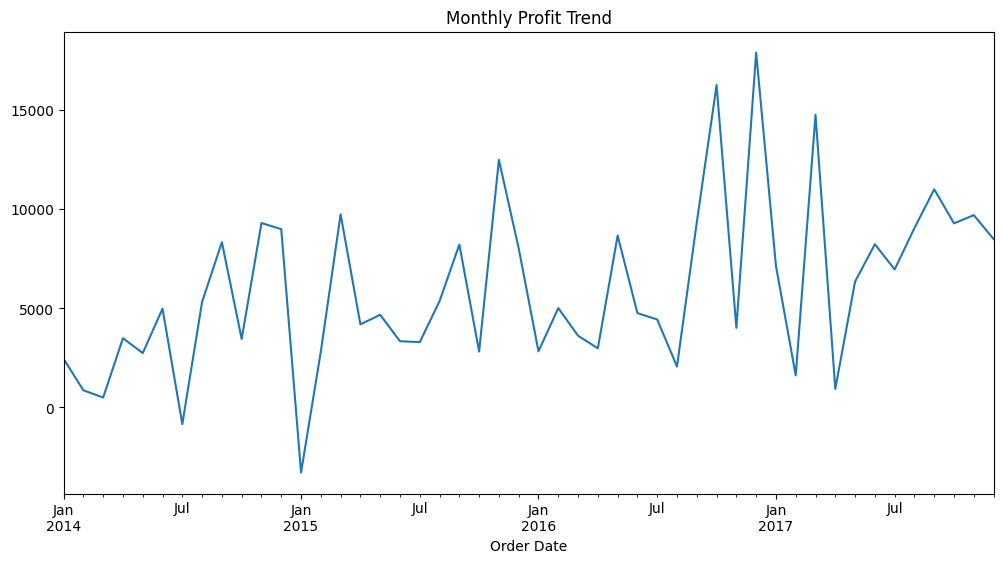

In [15]:
monthly_profit = (df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Profit'].sum())
plt.figure(figsize=(12,6))
monthly_profit.plot()
plt.title("Monthly Profit Trend")
plt.show()

Key Business Findings:
-> Technology generated the highest sales and profit
-> Furniture contributed significant revenue but very low profit
-> West region was the strongest market with over 725K in sales
-> California alone generated ~458K in revenue
-> Sales and profits show an overall upward trend with seasonal peaks
-> Certain months recorded losses, indicating opportunities for pricing optimization

In [16]:
monthly_sales = (df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index())
monthly_sales.head()

,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [17]:
monthly_sales['Month_Number'] = range(1, len(monthly_sales)+1)
monthly_sales.head()

,Order Date,Sales,Month_Number
0,2014-01-31,14236.895,1
1,2014-02-28,4519.892,2
2,2014-03-31,55691.009,3
3,2014-04-30,28295.345,4
4,2014-05-31,23648.287,5


In [18]:
train = monthly_sales.iloc[:-6]
test = monthly_sales.iloc[-6:]
print("Train:", train.shape)
print("Test:", test.shape)

Train: (42, 3)
Test: (6, 3)


In [19]:
from sklearn.linear_model import LinearRegression
X_train = train[['Month_Number']]
y_train = train['Sales']
X_test = test[['Month_Number']]
y_test = test['Sales']
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
predictions = model.predict(X_test)
predictions

array([55881.44601626, 56464.08820384, 57046.73039142, 57629.37257899,
       58212.01476657, 58794.65695415])

In [21]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("MAE:", mae)
print("R²:", r2)

MAE: 25585.295686881578
R²: -0.8917911965707161


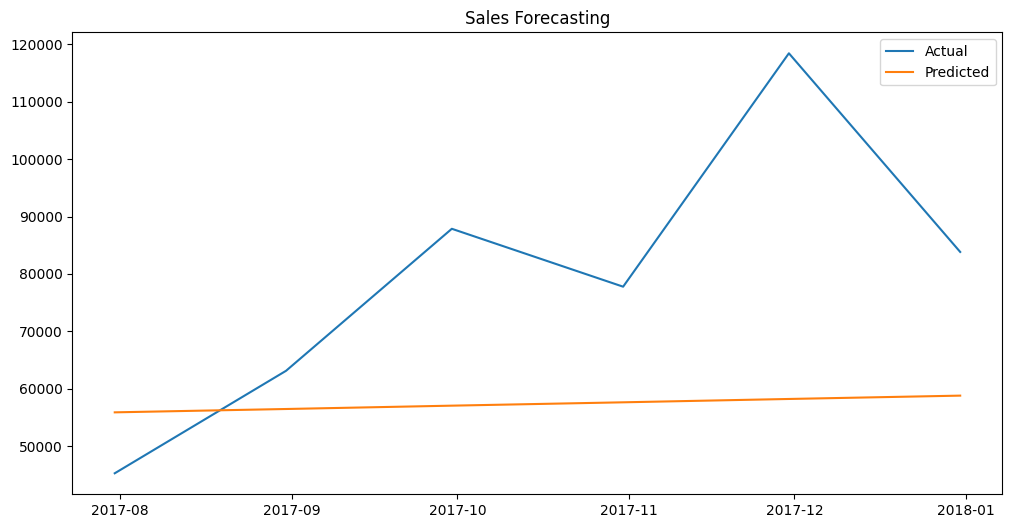

In [22]:
plt.figure(figsize=(12,6))
plt.plot(test['Order Date'], y_test, label='Actual')
plt.plot(test['Order Date'],predictions, label='Predicted')
plt.legend()
plt.title('Sales Forecasting')
plt.show()

In [27]:
!pip install statsmodels

  Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl.metadata (61 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 6.4 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.5 MB 6.3 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.5 MB 6.2 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.5 MB 6.0 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.5 MB 5.8 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 5.5 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 5.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.5 MB 4.8 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.5 MB 4.5 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 4.1 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.5 MB 3.9 MB/s eta 0:00:01
   ---------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
train_sales = train['Sales']
hw_model = ExponentialSmoothing(train_sales, trend='add', seasonal='add', seasonal_periods=12)
hw_fit = hw_model.fit()

In [24]:
predictions = hw_fit.forecast(len(test))

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(test['Sales'], predictions)
r2 = r2_score(test['Sales'], predictions)
print("MAE:", mae)
print("R²:", r2)

MAE: 14333.513230037619
R²: 0.342548667250854


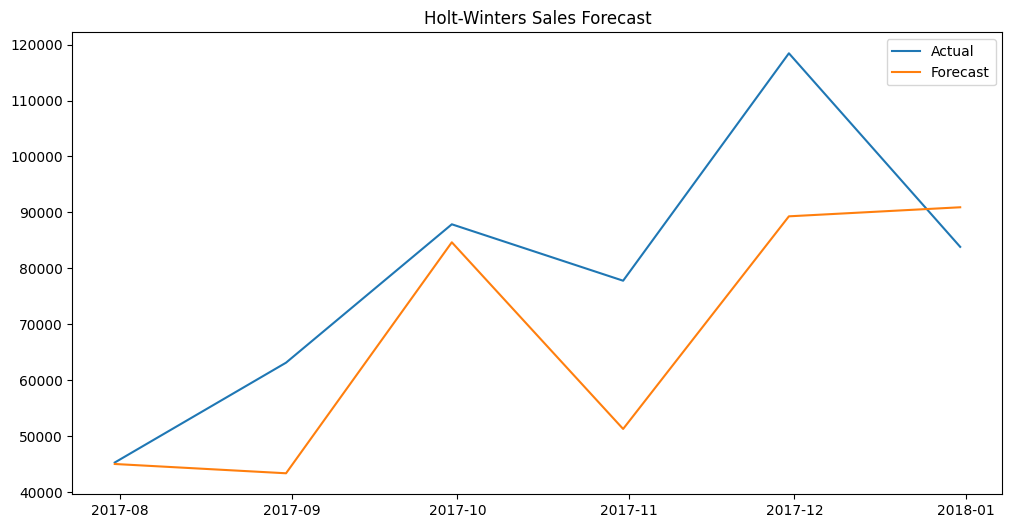

In [26]:
plt.figure(figsize=(12,6))
plt.plot(test['Order Date'], test['Sales'], label='Actual')
plt.plot(test['Order Date'], predictions, label='Forecast')
plt.legend()
plt.title("Holt-Winters Sales Forecast")
plt.show()

In [28]:
from prophet import Prophet
print("Prophet installed successfully")

Prophet installed successfully


In [29]:
prophet_df = monthly_sales.copy()
prophet_df.columns = ['ds', 'y', 'Month_Number']
prophet_df = prophet_df[['ds', 'y']]
prophet_df.head()

,ds,y
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [30]:
train_prophet = prophet_df.iloc[:-6]
test_prophet = prophet_df.iloc[-6:]
print(train_prophet.shape)
print(test_prophet.shape)

(42, 2)
(6, 2)


In [31]:
from prophet import Prophet
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(train_prophet)

10:24:55 - cmdstanpy - INFO - Chain [1] start processing
10:24:57 - cmdstanpy - INFO - Chain [1] done processing


In [32]:
future = model.make_future_dataframe(periods=6, freq='ME')

In [33]:
forecast = model.predict(future)
forecast[['ds','yhat']].tail()

,ds,yhat
43,2017-08-31,40128.751935
44,2017-09-30,83477.799322
45,2017-10-31,55960.844227
46,2017-11-30,86620.032898
47,2017-12-31,93619.069038


In [34]:
predictions = forecast['yhat'].tail(6).values
actual = test_prophet['y'].values

In [35]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
mae = mean_absolute_error(actual, predictions)
r2 = r2_score(actual, predictions)
print("MAE:", mae)
print("R²:", r2)

MAE: 15164.516868556299
R²: 0.300499314364002


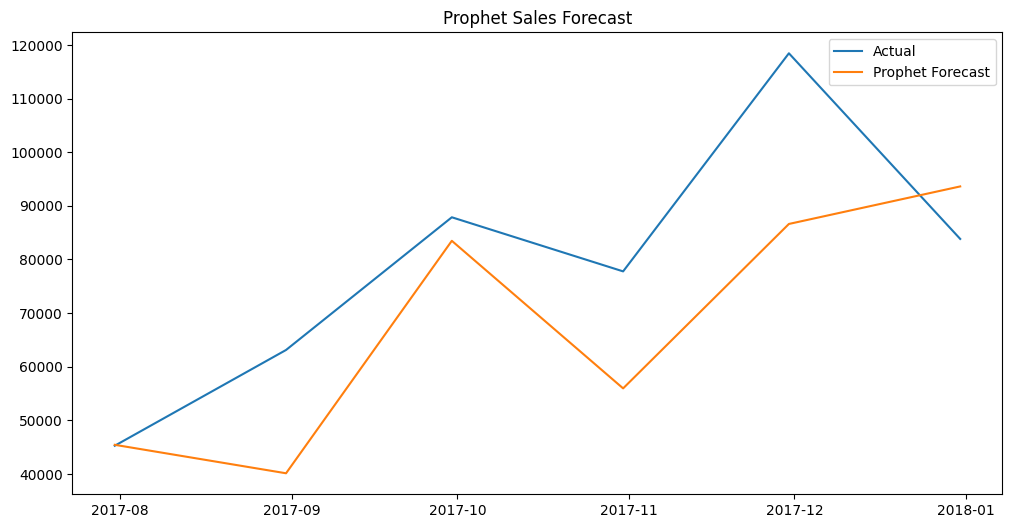

In [36]:
plt.figure(figsize=(12,6))
plt.plot(test_prophet['ds'], actual, label='Actual')
plt.plot(test_prophet['ds'], predictions, label='Prophet Forecast')
plt.legend()
plt.title("Prophet Sales Forecast")
plt.show()

In [37]:
monthly_sales.head()

,Order Date,Sales,Month_Number
0,2014-01-31,14236.895,1
1,2014-02-28,4519.892,2
2,2014-03-31,55691.009,3
3,2014-04-30,28295.345,4
4,2014-05-31,23648.287,5


In [38]:
import joblib
joblib.dump(hw_fit, "../models/sales_forecast_model.pkl")

['../models/sales_forecast_model.pkl']

In [39]:
import os
os.listdir("../models")

['sales_forecast_model.pkl']